# Color

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, LinearSegmentedColormap, Normalize, TwoSlopeNorm, LogNorm
from matplotlib import cm
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(2026)
rng = np.random.default_rng(2026)

## Foundation: `imshow()` and `colorbar()`

Before working with colors, it's essential to understand the core visualization functions.

### `ax.imshow()` Function

The `imshow()` function displays 2D data as an image where each data value is mapped to a color.

**Main Parameters:**

- `X` - 2D array-like data to display (required)
- `cmap` - colormap name or object (default: `'viridis'`), string or Colormap
- `aspect` - aspect ratio control (default: `'equal'`), options: `'auto'`, `'equal'`, or numeric value
- `origin` - position of [0,0] index (default: `'upper'`), options: `'upper'` or `'lower'`
- `extent` - data coordinate bounds (default: `None`), format: `[left, right, bottom, top]`
- `interpolation` - interpolation method (default: `'antialiased'`), options: `'nearest'`, `'bilinear'`, `'bicubic'`, etc.
- `vmin`, `vmax` - color scale limits (default: `None`, auto from data), numeric values
- `norm` - normalization instance (default: `None`), e.g., `LogNorm()`, `TwoSlopeNorm()`
- `alpha` - transparency level (default: `None`), range: 0.0 (transparent) to 1.0 (opaque)

Basic usage with different aspects

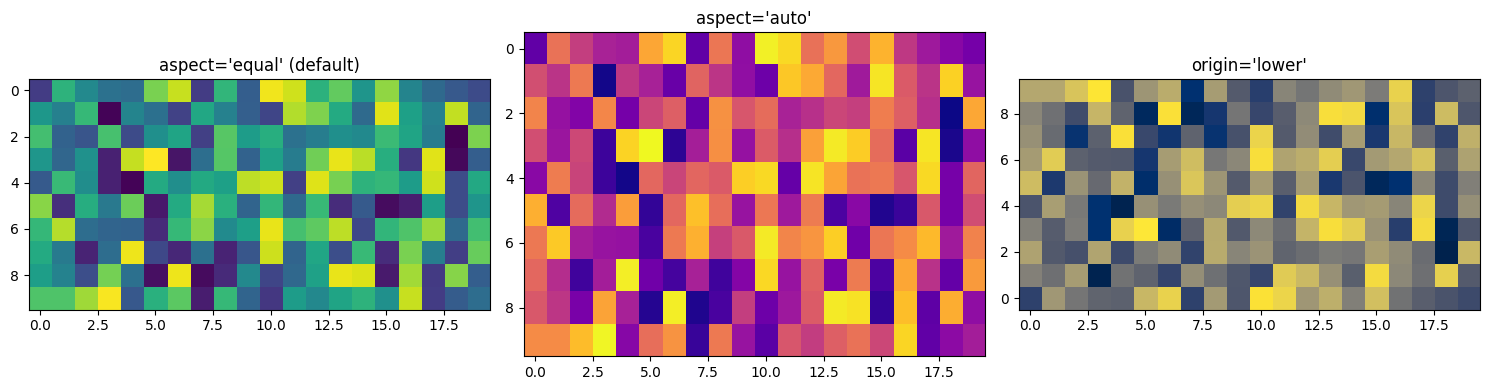

In [3]:
# Create sample data
data = rng.random((10, 20))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Default aspect
im1 = axes[0].imshow(data, cmap='viridis')
axes[0].set_title("aspect='equal' (default)")

# Auto aspect
im2 = axes[1].imshow(data, cmap='plasma', aspect='auto')
axes[1].set_title("aspect='auto'")

# Origin at bottom
im3 = axes[2].imshow(data, cmap='cividis', origin='lower')
axes[2].set_title("origin='lower'")

plt.tight_layout()
plt.show()

Using extent and interpolation

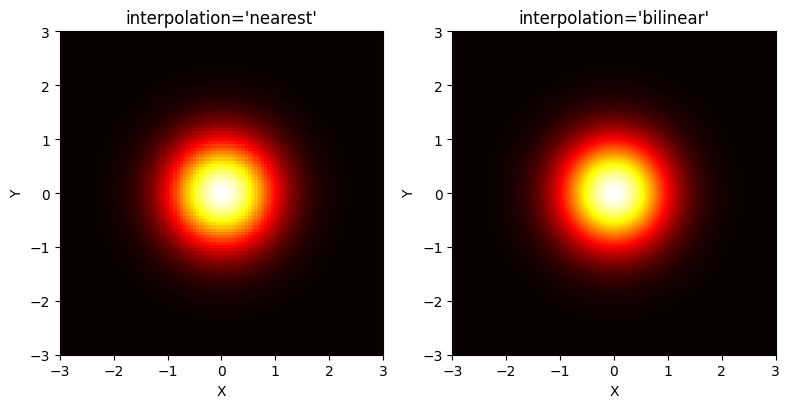

In [3]:
# Create smooth data
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = np.exp(-(X**2 + Y**2))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# With extent and nearest interpolation
im1 = axes[0].imshow(Z, extent= [-3, 3, -3, 3],
                     origin='lower',
                     interpolation= 'nearest', cmap='hot')
axes[0].set_title("interpolation='nearest'")
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')

# With bilinear interpolation
im2 = axes[1].imshow(Z, extent=[-3, 3, -3, 3],
                     origin='lower',
                     interpolation= ('bilinear'), cmap='hot')
axes[1].set_title("interpolation='bilinear'")
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')

plt.tight_layout()
plt.show()

### `fig.colorbar()` Function

The `.colorbar()` function adds a color scale legend to visualizations. Keep in mind that this function returns a colorbar object

**Main Parameters:**

- `mappable` - the image/plot object to create colorbar for (required), return value from `imshow()`, `contourf()`, etc.
- `ax` - axes to steal space from (default: `None`), Axes object or list of Axes
- `cax` - axes to use for colorbar (default: `None`), creates new Axes if `None`
- `orientation` - colorbar direction (default: `'vertical'`), options: `'vertical'` or `'horizontal'`
- `label` - colorbar label text (default: `''`), string
- `shrink` - size scaling factor (default: `1.0`), range: 0.0 to 1.0
- `pad` - spacing from axes (default: `0.15` for vertical, `0.05` for horizontal), numeric value
- `extend` - extension triangles (default: `'neither'`), options: `'neither'`, `'both'`, `'min'`, `'max'`
- `ticks` - tick locations (default: `None`, automatic), list or array
- `format` - tick label format (default: `None`), string or Formatter object

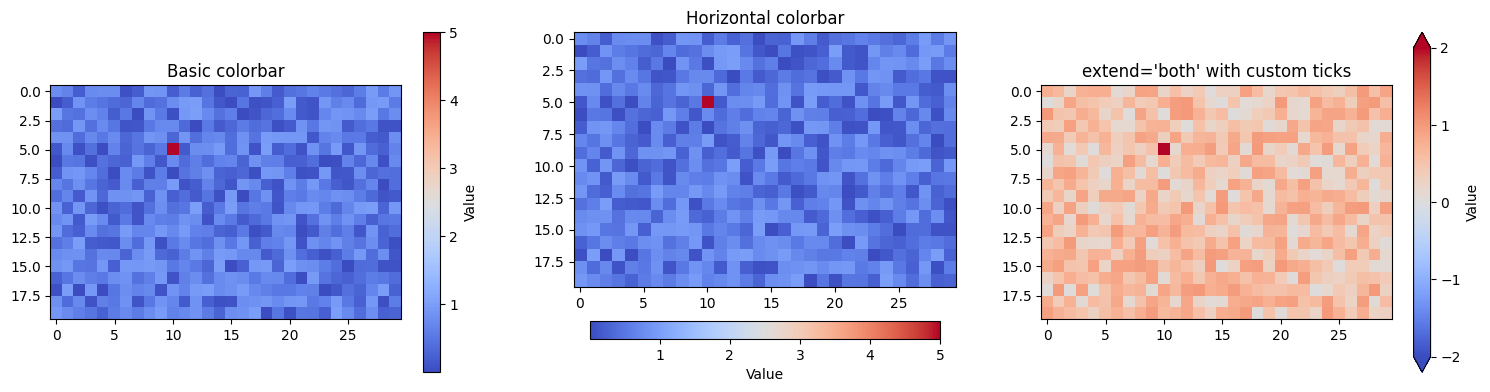

In [4]:
# Create data with outliers
data = rng.random((20, 30))
data[5, 10] = 5  # Add outlier

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Basic colorbar
im1 = axes[0].imshow(data, cmap='coolwarm')
fig.colorbar(im1, ax=axes[0], label='Value')
axes[0].set_title('Basic colorbar')

# Horizontal colorbar with shrink
im2 = axes[1].imshow(data, cmap='coolwarm')
fig.colorbar(im2, ax=axes[1], orientation='horizontal', 
             label='Value', shrink=0.8, pad=0.1)
axes[1].set_title('Horizontal colorbar')

# Colorbar with custom ticks and extend
im3 = axes[2].imshow(data, cmap='coolwarm', vmin=-2, vmax=2)
cbar = fig.colorbar(im3, ax=axes[2], label='Value', 
                   extend='both', ticks=[-2,-1,0,1,2])
axes[2].set_title("extend='both' with custom ticks")

plt.tight_layout()
plt.show()

Dealing with long colorbar axes

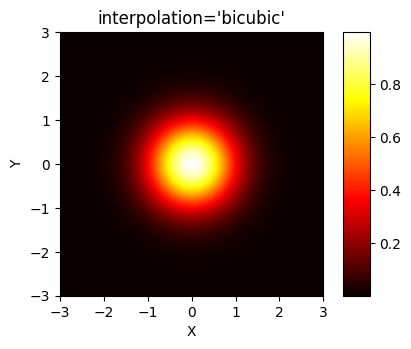

In [5]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
# Create smooth data
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = np.exp(-(X**2 + Y**2))

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

# With extent and nearest interpolation
im = ax.imshow(Z, extent=[-3, 3, -3, 3],
                     origin='lower', 
                     interpolation='bicubic', cmap='hot')

divider= make_axes_locatable(ax)
cax = divider.append_axes('right', size='10%', pad=0.2)
fig.colorbar(im, cax= cax) 

ax.set_title("interpolation='bicubic'")
ax.set_xlabel('X')
ax.set_ylabel('Y')

plt.show()


## Color Specification and Color Spaces

As we have already encountered, Matplotlib accepts colors in multiple formats:

**Color Specification Methods:**

- **Named colors**: String color names (e.g., `'red'`, `'steelblue'`, `'coral'`)
- **RGB tuple**: `(r, g, b)` with values in range [0, 1]
- **RGBA tuple**: `(r, g, b, a)` with values in range [0, 1], where `a` is alpha (transparency)
- **Hexadecimal**: String format `'#RRGGBB'` (e.g., `'#FF6B35'`)
- **Grayscale**: String representation of intensity `'0.0'` (black) to `'1.0'` (white)

**`mcolors.CSS4_COLORS`** - Dictionary containing 148 named colors from CSS4 specification.
- **Returns**: `dict` - Keys are color names (str), values are hex codes (str)
- **Example**: `mcolors.CSS4_COLORS['steelblue']` returns `'#4682b4'`

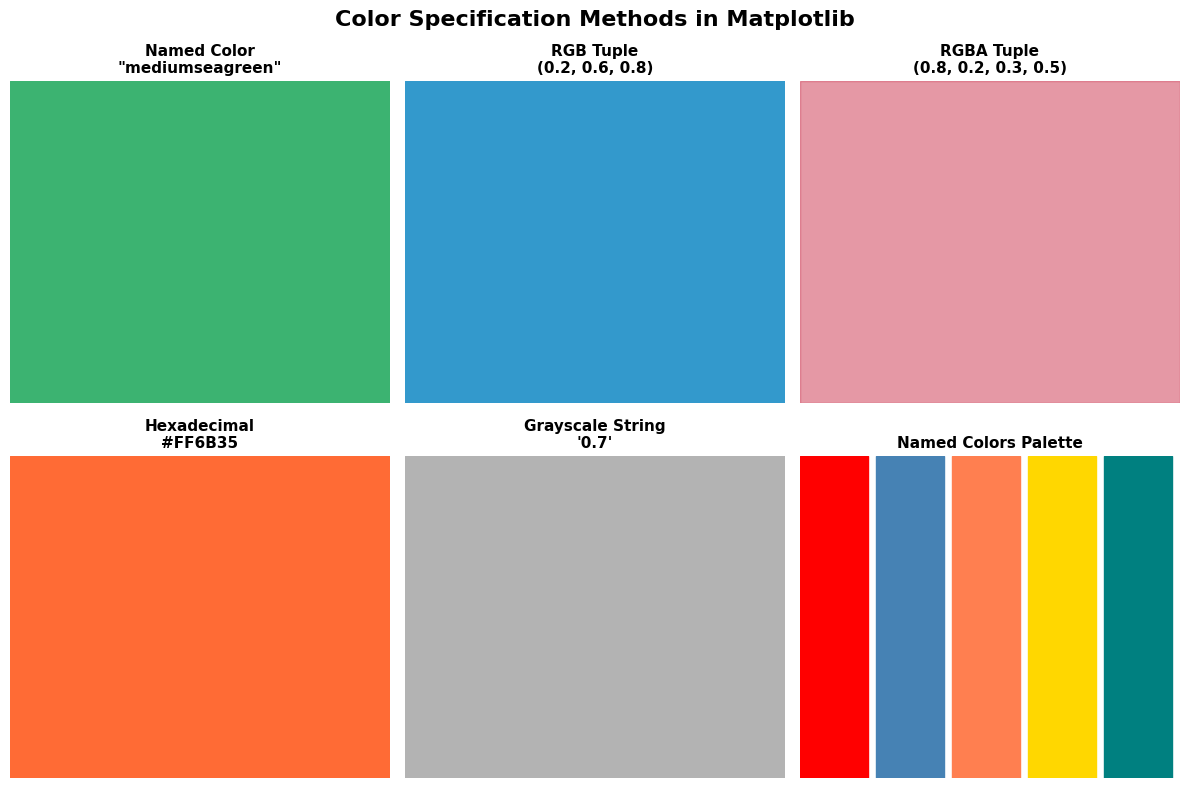

In [6]:
# Demonstrate different color specification methods
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

options = [('mediumseagreen', 'Named Color\n"mediumseagreen"'),
           ((0.2, 0.6, 0.8), 'RGB Tuple\n(0.2, 0.6, 0.8)' ),
           ((0.8, 0.2, 0.3, 0.5), 'RGBA Tuple\n(0.8, 0.2, 0.3, 0.5)' ),
           ('#FF6B35', 'Hexadecimal\n#FF6B35' ),
           ('0.7', "Grayscale String\n'0.7'" )]

# first five examples
for ax, (color, title) in zip(axes[:-1], options):
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, color=color))
    ax.set_title(title, size=11, fontweight='bold')
    ax.axis('off')    

# example six
color_names = ['red', 'steelblue', 'coral', 'gold', 'teal']
for i, color in enumerate(color_names):
    axes[5].add_patch(plt.Rectangle((i*0.2, 0), 0.18, 1, color=color, edgecolor='black', linewidth=1))
axes[5].set_title('Named Colors Palette', size=11, fontweight='bold')
axes[5].axis('off')

fig.suptitle('Color Specification Methods in Matplotlib', fontsize=16, fontweight='bold')
fig.tight_layout()

plt.show()

## Color Space Conversions

Matplotlib provides some functions to convert between different color spaces, enabling precise color manipulation. For other conversions you need additional Python packages.

**Primary Conversion Functions:**

- **`mcolors.to_rgb(c)`** - Convert any color format to RGB tuple (values in [0, 1])
- **`mcolors.to_rgba(c, alpha=None)`** - Convert to RGBA tuple, optionally setting alpha
- **`mcolors.to_hex(c, keep_alpha=False)`** - Convert to hexadecimal string
- **`mcolors.rgb_to_hsv(rgb)`** - Convert RGB to HSV (Hue, Saturation, Value) color space
- **`mcolors.hsv_to_rgb(hsv)`** - Convert HSV back to RGB

**HSV Color Space**: Represents colors using Hue (0-1, color type), Saturation (0-1, color intensity), and Value (0-1, brightness). Useful for programmatic color manipulation.

In [7]:
# Specify named color
color_name = 'coral'

In [8]:
# conver to rgb without and with transparency
rgb = mcolors.to_rgb(color_name)
rgba = mcolors.to_rgba(color_name, alpha=0.7)
rgb, rgba

((1.0, 0.4980392156862745, 0.3137254901960784),
 (1.0, 0.4980392156862745, 0.3137254901960784, 0.7))

In [9]:
# convert to hex
hex_color = mcolors.to_hex(color_name)
hex_color

'#ff7f50'

In [10]:
# convert rgb to hex 
rgb_tuple = (0.1, 0.5, 0.8)
hex_color = mcolors.to_hex(rgb_tuple)
hex_color 

'#1a80cc'

In [11]:
# convert hex to rgb
hex_val = '#3498db'
rgb_color = mcolors.to_rgb(hex_val)
rgb_color

(0.20392156862745098, 0.596078431372549, 0.8588235294117647)

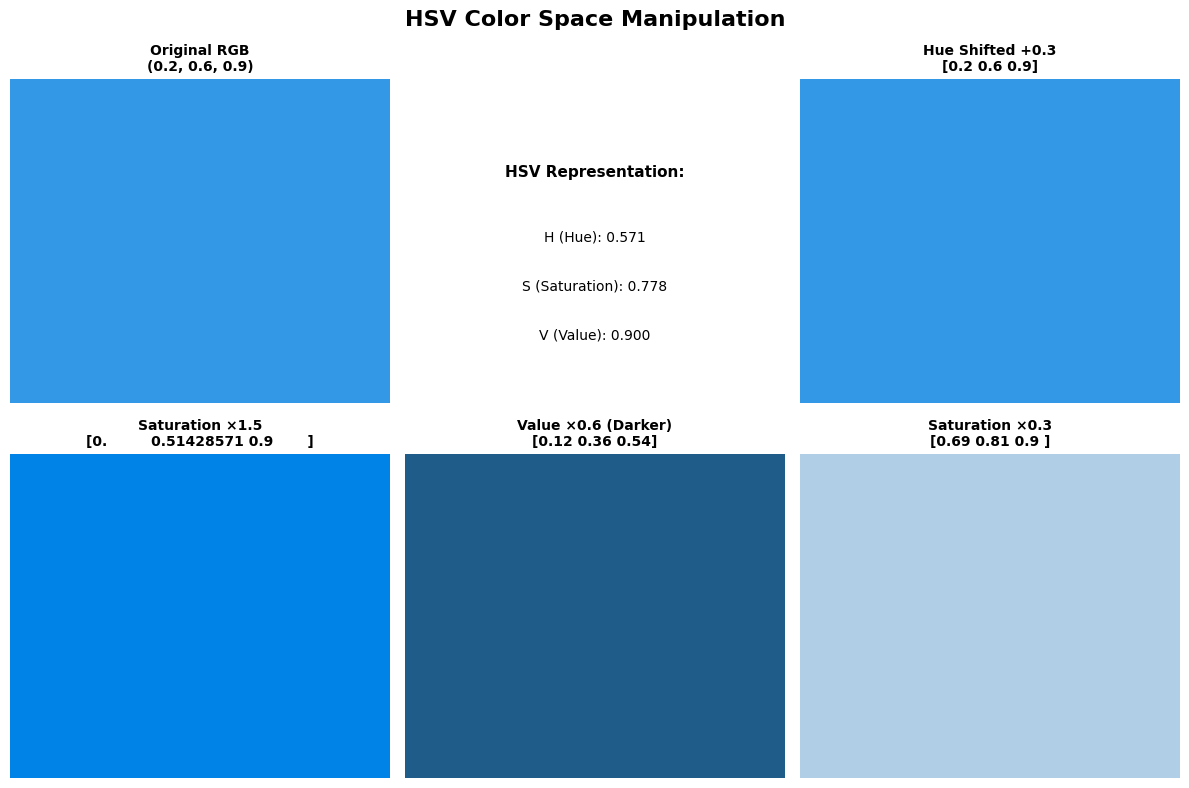

In [12]:
# Example 2: HSV color space manipulations
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Original color
base_color_rgb = (0.2, 0.6, 0.9)
axes[0, 0].add_patch(plt.Rectangle((0, 0), 1, 1, color=base_color_rgb))
axes[0, 0].set_title(f'Original RGB\n{base_color_rgb}', size=10, fontweight='bold')
axes[0, 0].axis('off')

# Convert to HSV
hsv = mcolors.rgb_to_hsv(base_color_rgb)
axes[0, 1].text(0.5, 0.7, 'HSV Representation:', ha='center', size=11, fontweight='bold')
axes[0, 1].text(0.5, 0.5, f'H (Hue): {hsv[0]:.3f}', ha='center', size=10)
axes[0, 1].text(0.5, 0.35, f'S (Saturation): {hsv[1]:.3f}', ha='center', size=10)
axes[0, 1].text(0.5, 0.2, f'V (Value): {hsv[2]:.3f}', ha='center', size=10)
axes[0, 1].axis('off')

# Rotate hue (change color while keeping saturation/value)
hsv_rotated = (hsv[0]+3)% 1.0, hsv[1], hsv[2]
              #     ^ keeps it within 0.0 and 1.0
rgb_rotated = mcolors.hsv_to_rgb(hsv_rotated)
axes[0, 2].add_patch(plt.Rectangle((0, 0), 1, 1, color=rgb_rotated))
axes[0, 2].set_title(f'Hue Shifted +0.3\n{rgb_rotated}', fontsize=10, fontweight='bold')
axes[0, 2].axis('off')

# Increase saturation
hsv_saturated = hsv[0], min(hsv[1]*1.5, 1.0), hsv[2]
              #                      ^ makes sure that saturation <= 1.0
rgb_saturated = mcolors.hsv_to_rgb(hsv_saturated)
axes[1, 0].add_patch(plt.Rectangle((0, 0), 1, 1, color=rgb_saturated))
axes[1, 0].set_title(f'Saturation ×1.5\n{rgb_saturated}', fontsize=10, fontweight='bold')
axes[1, 0].axis('off')

# Decrease value (darken)
hsv_darkened = hsv[0], hsv[1], hsv[2] * 0.6
rgb_darkened = mcolors.hsv_to_rgb(hsv_darkened)
axes[1, 1].add_patch(plt.Rectangle((0, 0), 1, 1, color=rgb_darkened))
axes[1, 1].set_title(f'Value ×0.6 (Darker)\n{rgb_darkened}', fontsize=10, fontweight='bold')
axes[1, 1].axis('off')

# Desaturate (move toward gray)
hsv_desaturated = hsv[0], hsv[1]*0.3, hsv[2]
rgb_desaturated = mcolors.hsv_to_rgb(hsv_desaturated)
axes[1, 2].add_patch(plt.Rectangle((0, 0), 1, 1, color=rgb_desaturated))
axes[1, 2].set_title(f'Saturation ×0.3\n{rgb_desaturated}', fontsize=10, fontweight='bold')
axes[1, 2].axis('off')

fig.suptitle('HSV Color Space Manipulation', fontsize=16, fontweight='bold')
fig.tight_layout()

plt.show()

## Understanding Colormap Categories

A colormap maps scalar data values to colors. Choosing the right colormap category is crucial for accurate data visualization.

### Sequential Colormaps

Used for data that progresses from low to high values with **no meaningful center**.

**When to use:** Elevation, temperature (absolute), density, probability, count data, measurements with natural zero point

**Recommended:** `'viridis'`, `'plasma'`, `'cividis'`, `'Blues'`, `'YlOrRd'`, `'Greens'`

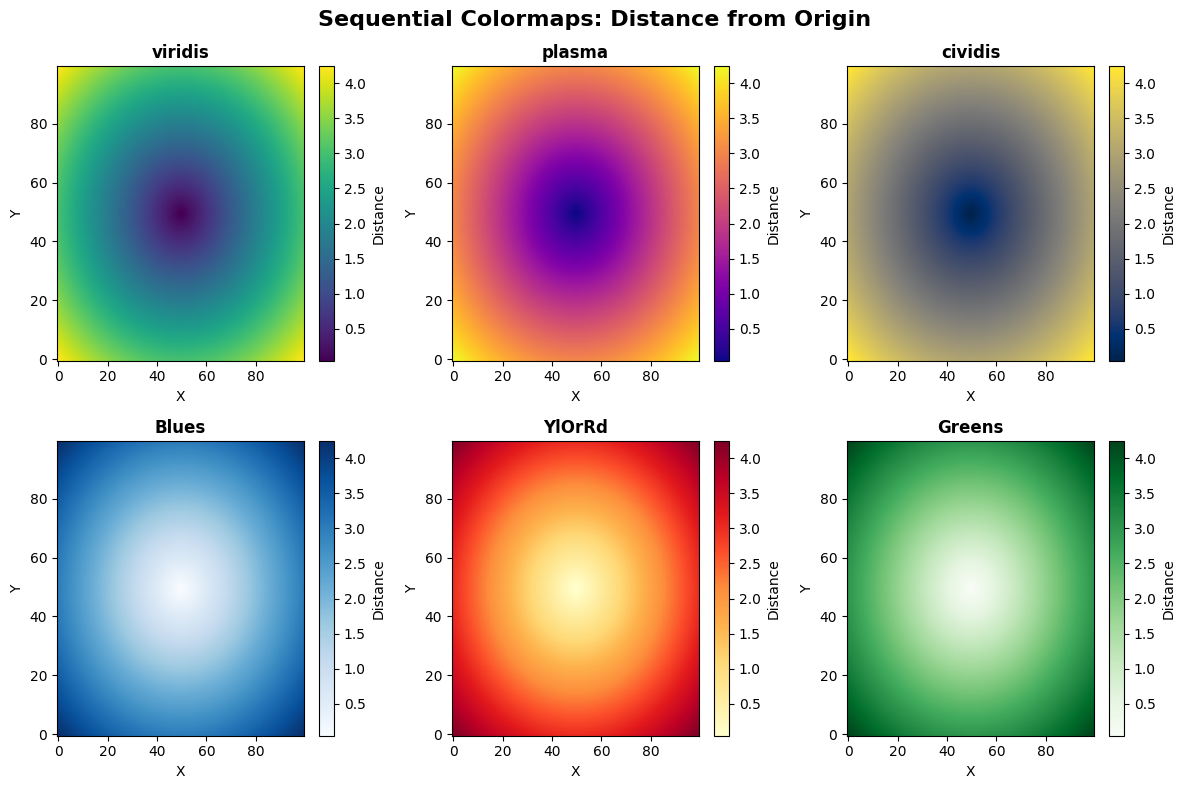

In [13]:
sequential_cmaps = ['viridis', 'plasma', 'cividis', 'Blues', 'YlOrRd', 'Greens']

# Create data
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = np.sqrt(X**2 + Y**2)  # Distance from origin (always positive)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, cmap_name in zip(axes, sequential_cmaps):
    im = ax.imshow(Z, cmap=cmap_name, aspect='auto', origin='lower')
    fig.colorbar(im, ax=ax, label='Distance')
    ax.set_title(f'{cmap_name}', size=12, weight='bold')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')


fig.suptitle('Sequential Colormaps: Distance from Origin', size=16, weight='bold')
fig.tight_layout()
plt.show()

### Diverging Colormaps

Used for data with a **meaningful center point** (often zero), where values diverge in two directions.

**When to use:** Temperature anomaly, correlation coefficients, change from baseline, profit/loss, pH values, any data where positive and negative deviations from a center are meaningful

**Recommended:** `'RdBu'`, `'coolwarm'`, `'seismic'`, `'RdYlBu'`, `'PiYG'`, `'BrBG'`

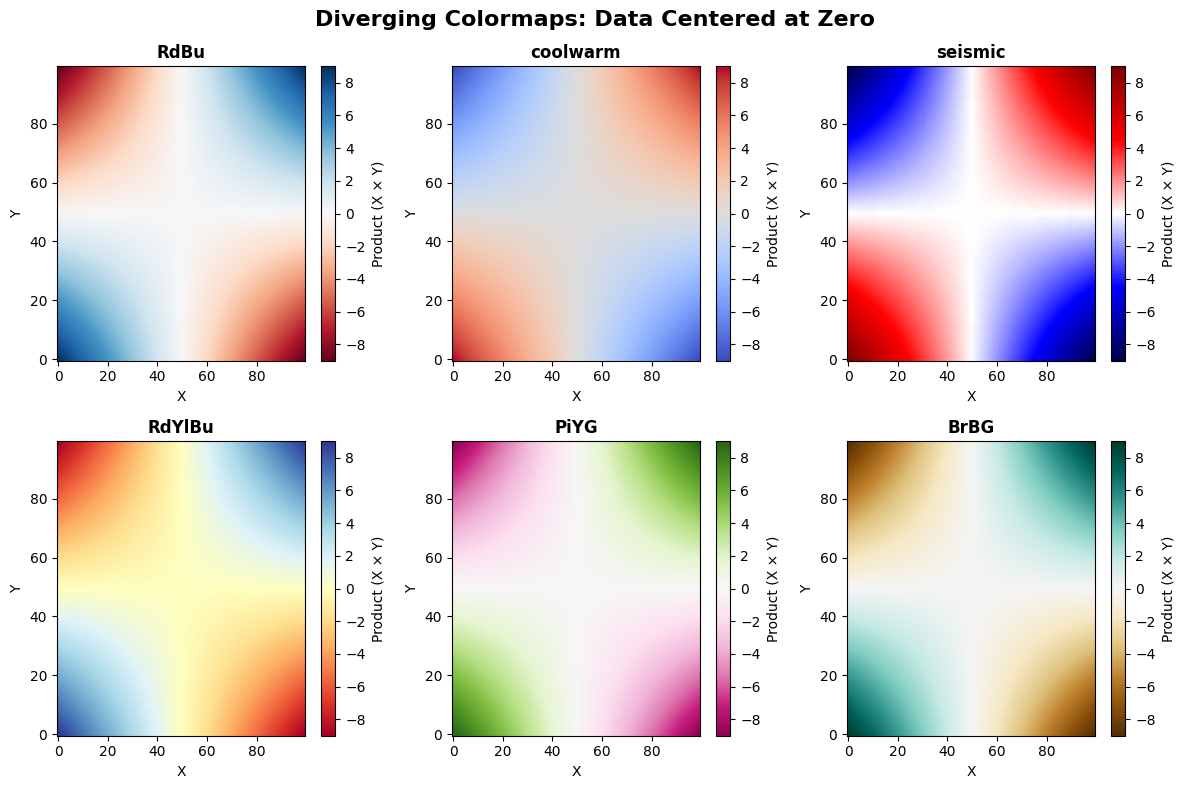

In [14]:
diverging_cmaps = ['RdBu', 'coolwarm', 'seismic', 'RdYlBu', 'PiYG', 'BrBG']

# Diverging colormap example
Z_diverging = X * Y  # Data centered at zero with positive and negative values

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, cmap_name in zip(axes, diverging_cmaps):
    im = ax.imshow(Z_diverging, cmap=cmap_name, aspect='auto', origin='lower')
    ax.set_title(f'{cmap_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    fig.colorbar(im, ax=ax, label='Product (X × Y)')

fig.suptitle('Diverging Colormaps: Data Centered at Zero', fontsize=16, fontweight='bold')
fig.tight_layout()
plt.show()

###  Qualitative Colormaps

Used for categorical or discrete data without inherent ordering.

**When to use:** Categories, labels, regions, groups, classifications, nominal data

**Recommended:** `'tab10'`, `'tab20'`, `'Set1'`, `'Set2'`, `'Paired'`, `'Accent'`

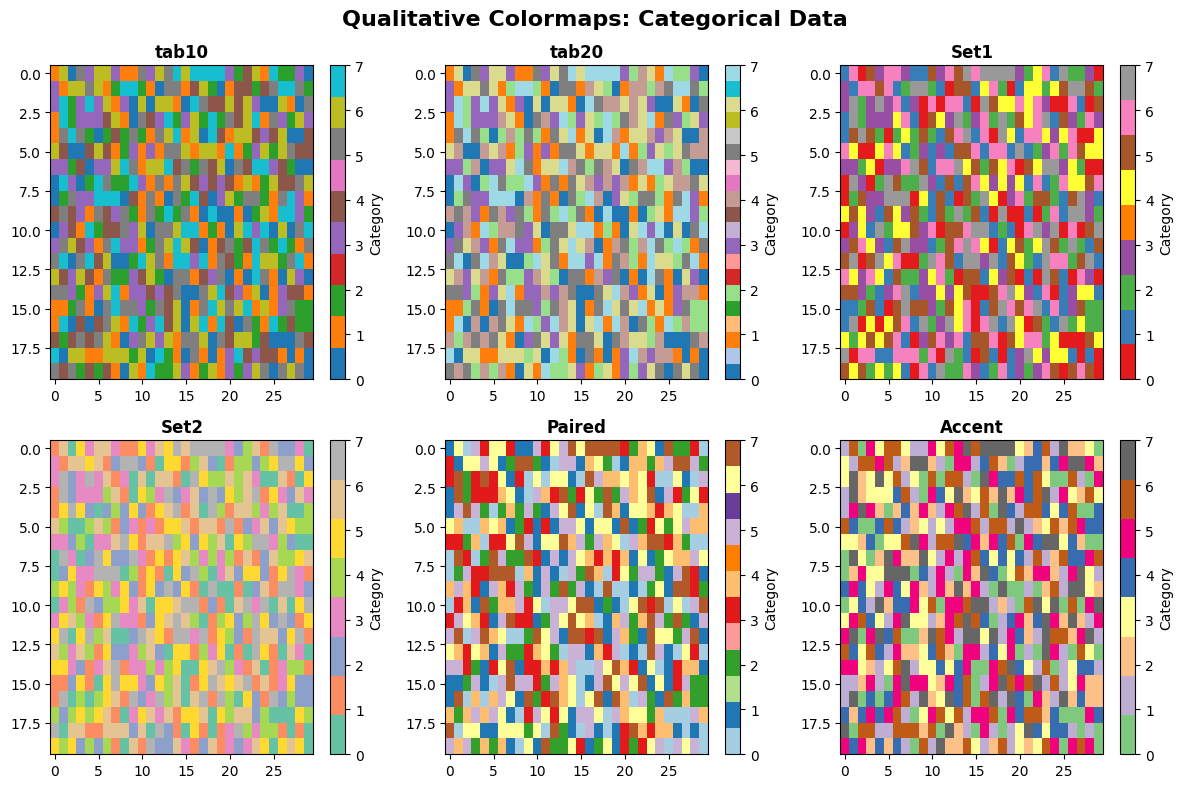

In [15]:
qualitative_cmaps = ['tab10', 'tab20', 'Set1', 'Set2', 'Paired', 'Accent']

# Qualitative colormap example
categories = rng.integers(0, 8, size=(20, 30))

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, cmap_name in zip(axes, qualitative_cmaps):
    im = ax.imshow(categories, cmap=cmap_name, aspect='auto', interpolation='nearest')
    ax.set_title(f'{cmap_name}', fontsize=12, fontweight='bold')
    cbar = fig.colorbar(im, ax=ax, label='Category')
    cbar.set_ticks(range(8))

fig.suptitle('Qualitative Colormaps: Categorical Data', fontsize=16, fontweight='bold')
fig.tight_layout()
fig.show()

### Cyclic Colormaps

Used for periodic data that wraps around (values at minimum and maximum are equivalent).

**When to use:** Angles (0-360°), phases, time of day (24-hour), compass directions, periodic phenomena, wind direction

**Recommended:** `'twilight'`, `'hsv'`, `'twilight_shifted'`

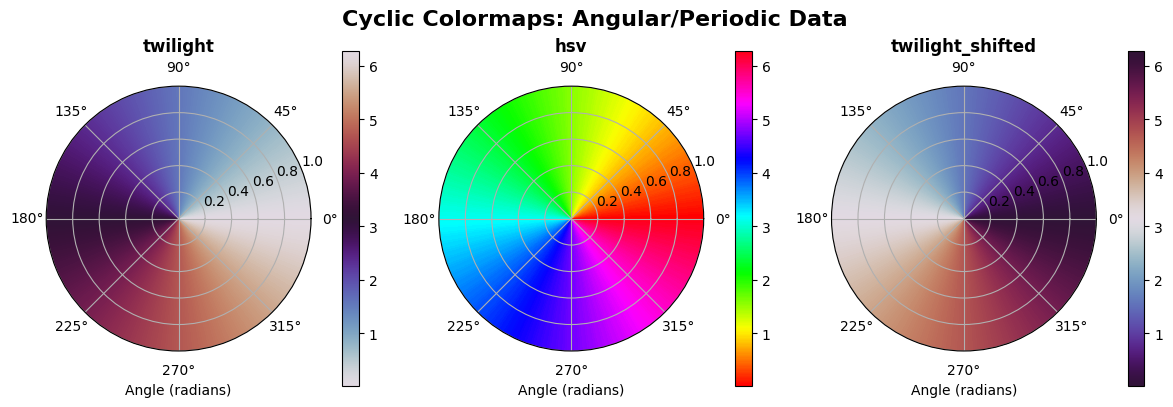

In [16]:
# Cyclic colormap example

cyclic_cmaps = ['twilight', 'hsv', 'twilight_shifted']

# Resolution
n_theta = 360
n_r = 200

# Bin edges (important!)
theta_edges = np.linspace(0, 2*np.pi, n_theta + 1)
r_edges = np.linspace(0, 1.0, n_r + 1)

# Cell centers
theta_centers = (theta_edges[:-1] + theta_edges[1:]) / 2

# Data: angle only, broadcast over radius
data = np.tile(theta_centers, (n_r, 1))


fig, axes = plt.subplots(1, 3, figsize=(12, 4), subplot_kw={'projection': 'polar'})
for ax, cmap_name in zip(axes, cyclic_cmaps):
    pcm = ax.pcolormesh(
        theta_edges,
        r_edges,
        data,
        cmap=cmap_name,
        shading='flat'
    )
    ax.set_title(f'{cmap_name}', size=12, weight='bold')
    ax.set_xlabel('Angle (radians)')
    fig.colorbar(pcm, ax=ax, pad= 0.09)

plt.suptitle('Cyclic Colormaps: Angular/Periodic Data', size=16, weight='bold')
plt.tight_layout()
plt.show()

### Perceptually Uniform Colormaps

Perceptually uniform colormaps ensure that equal steps in data value produce equal perceived steps in color. This prevents visual artifacts where the eye perceives false boundaries or gradients in the data.

**Why it matters:** Non-uniform colormaps like `'jet'` or `'rainbow'` create perceived "peaks" and "valleys" in smooth data, leading to misinterpretation. When converted to grayscale, these problems become even more apparent.

**Recommended perceptually uniform colormaps:**
- `'viridis'` - Blue to yellow, excellent general-purpose
- `'plasma'` - Purple to yellow, higher contrast
- `'inferno'` - Black to yellow through purple/red
- `'magma'` - Black to white through purple/red
- `'cividis'` - Blue to yellow, optimized for color vision deficiency

In the following example we convert the color values in each colormap to their perceived brightness (gray). The coefficients: 0.299, 0.587, 0.114 represent how human vision perceives the brightness of red, green, and blue channels:
- Green contributes the most 58.7%    
- Red contributes moderately 29.9%   
- And Blue the least  only 11.4%   

In [17]:
# Create data
x = np.linspace(0, 1, 256)
gradient = x.reshape(1, -1)

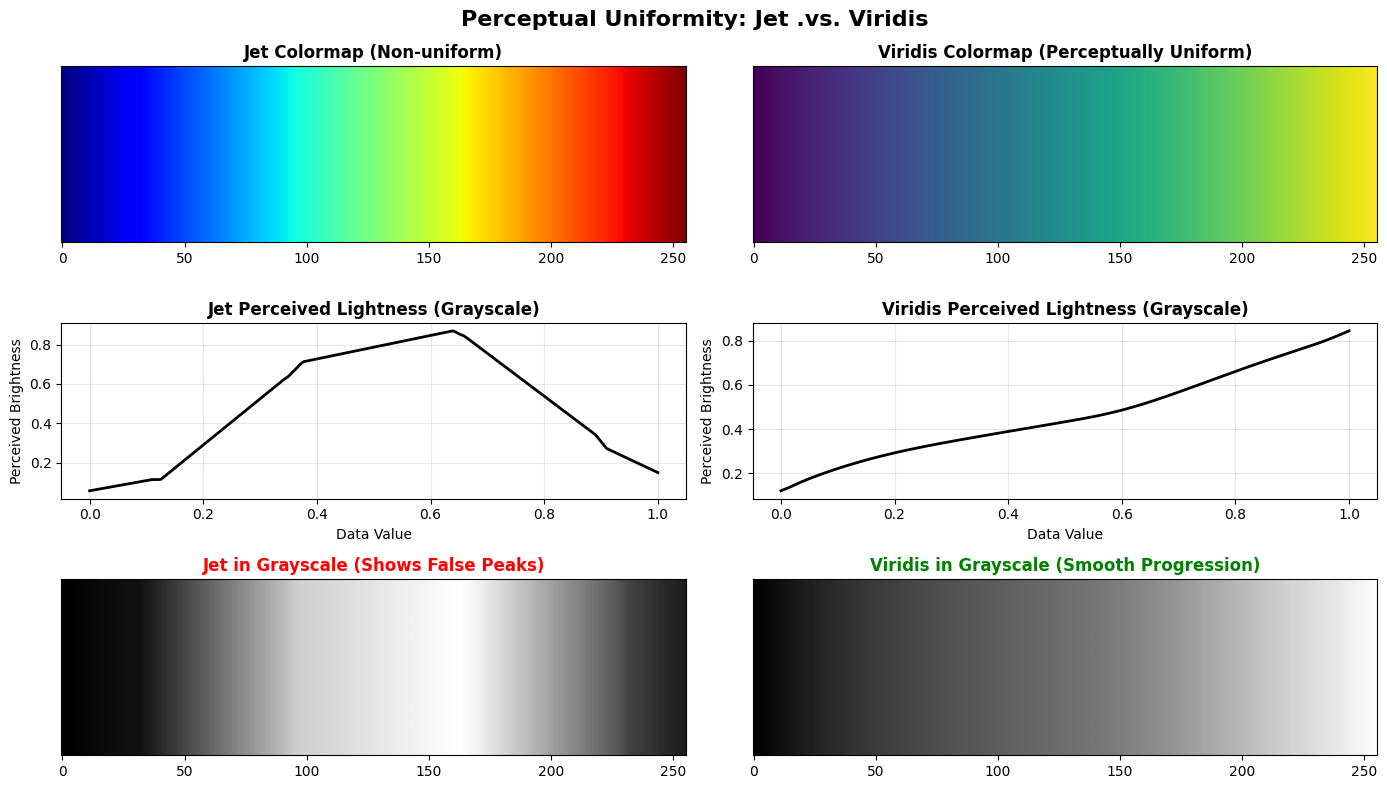

In [18]:
# Demonstrate perceptual uniformity issues with jet vs viridis
fig, axes = plt.subplots(3, 2, figsize=(14, 8))

# Jet colormap
axes[0, 0].imshow(gradient, cmap='jet', aspect='auto')
axes[0, 0].set_title('Jet Colormap (Non-uniform)', size=12, weight='bold')
axes[0, 0].set_yticks([])

# Extracting perceived brightness from jet colormap
jet_cmap = plt.get_cmap('jet')
jet_colors = jet_cmap(x)
jet_gray = np.dot(jet_colors[:,:3], [0.299, 0.587, 0.114])  # RGB to grayscale
# The dot product computes for each color value its (perceived brightness) grayscale = 0.299×R + 0.587×G + 0.114×B
axes[1, 0].plot(x, jet_gray, 'k-', lw=2)
axes[1, 0].set_title('Jet Perceived Lightness (Grayscale)', size=12, weight='bold')
axes[1, 0].set_xlabel('Data Value')
axes[1, 0].set_ylabel('Perceived Brightness')
axes[1, 0].grid(True, alpha=0.3)

# Jet converted to grayscale image (two peaks)
axes[2, 0].imshow(np.tile(jet_gray, (10, 1)), cmap='gray', aspect='auto')
axes[2, 0].set_title('Jet in Grayscale (Shows False Peaks)', size=12, weight='bold', color='red')
axes[2, 0].set_yticks([])

# Extracting perceived brightness from Viridis colormap
axes[0, 1].imshow(gradient, cmap='viridis', aspect='auto')
axes[0, 1].set_title('Viridis Colormap (Perceptually Uniform)', size=12, weight='bold')
axes[0, 1].set_yticks([])

# Viridis in grayscale - smooth monotonic progression
viridis_cmap = plt.get_cmap('viridis')
viridis_colors = viridis_cmap(x)
viridis_gray = np.dot(viridis_colors[:, :3], [0.299, 0.587, 0.114])
axes[1, 1].plot(x, viridis_gray, 'k-', lw=2)
axes[1, 1].set_title('Viridis Perceived Lightness (Grayscale)', size=12, weight='bold')
axes[1, 1].set_xlabel('Data Value')
axes[1, 1].set_ylabel('Perceived Brightness')
axes[1, 1].grid(True, alpha=0.3)

# Viridis converted to grayscale image
axes[2, 1].imshow(np.tile(viridis_gray, (10, 1)), cmap='gray', aspect='auto')
axes[2, 1].set_title('Viridis in Grayscale (Smooth Progression)', size=12, weight='bold', color='green')
axes[2, 1].set_yticks([])

plt.suptitle('Perceptual Uniformity: Jet .vs. Viridis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

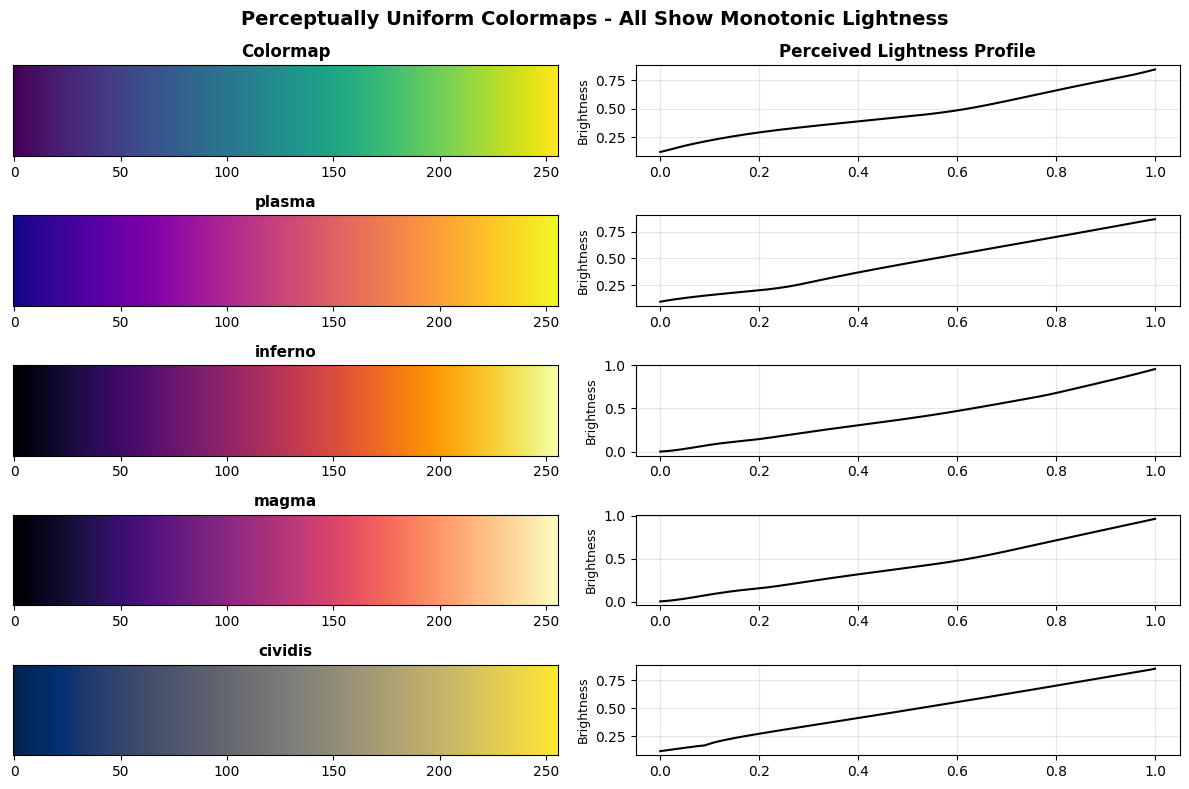

In [19]:
# Compare all perceptually uniform colormaps
uniform_cmaps = ['viridis', 'plasma', 'inferno', 'magma', 'cividis']

fig, axes = plt.subplots(len(uniform_cmaps), 2, figsize=(12, 8))

for i, cmap_name in enumerate(uniform_cmaps):
    # Show colormap
    axes[i, 0].imshow(gradient, cmap=cmap_name, aspect='auto')
    axes[i, 0].set_title(f'{cmap_name}', size=11, weight='bold')
    axes[i, 0].set_yticks([])
    
    # Show lightness profile
    cmap = plt.get_cmap(cmap_name)
    colors = cmap(x)
    gray = np.dot(colors[:, :3], [0.299, 0.587, 0.114])
    axes[i, 1].plot(x, gray, color='black', linewidth=1.5)
    axes[i, 1].set_ylabel('Brightness', fontsize=9)
    axes[i, 1].grid(True, alpha=0.3)

axes[0, 0].set_title('Colormap', size=12, weight='bold')
axes[0, 1].set_title('Perceived Lightness Profile', size=12, weight='bold')

plt.suptitle('Perceptually Uniform Colormaps - All Show Monotonic Lightness', 
             size=14, weight='bold')
plt.tight_layout()
plt.show()

## Accessing Colormaps

Matplotlib provides several ways to access and retrieve colormaps:

- `plt.get_cmap(name, lut=None)` retrieves a colormap object by its name.

**Parameters:**
- `name` - colormap name (default: `None`, returns default colormap), string
- `lut` - number of discrete colors (default: `None`, uses colormap default), integer

**Returns:** `Colormap` object

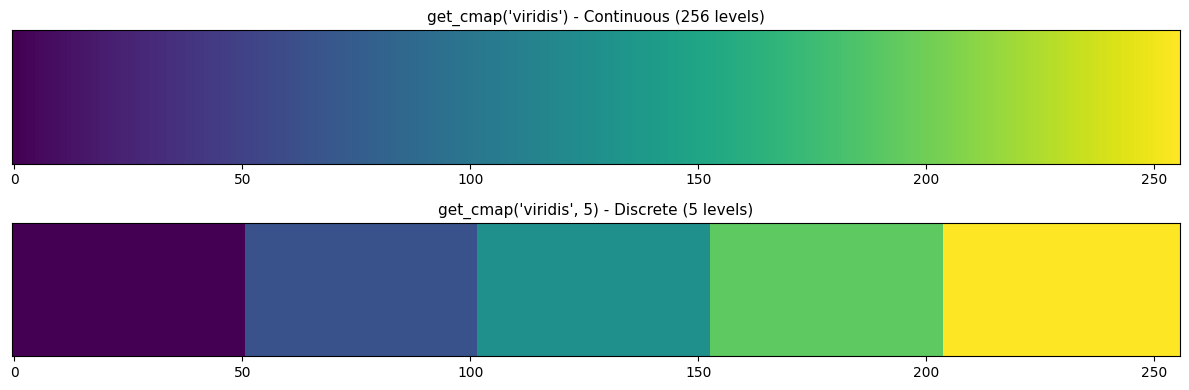

In [20]:
# Get colormaps by name
viridis = plt.get_cmap('viridis')

# Get colormap with specific number of discrete levels
n = 5
viridis_n = plt.get_cmap('viridis', n)

fig, axes = plt.subplots(2, 1, figsize=(12, 4))

# Continuous (default)
axes[0].imshow(gradient, cmap=viridis, aspect='auto')
axes[0].set_title("get_cmap('viridis') - Continuous (256 levels)", size=11)
axes[0].set_yticks([])

# Discrete (10 levels)
axes[1].imshow(gradient, cmap=viridis_n, aspect='auto')
axes[1].set_title(f"get_cmap('viridis', {n}) - Discrete ({n} levels)", size=11)
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

### Listing Available Colormaps

**`plt.colormaps()`** returns a list of all registered colormap names.

In [21]:
# List all available colormaps
all_cmaps = plt.colormaps()
print(f"Total number of colormaps: {len(all_cmaps)}\n")

Total number of colormaps: 180



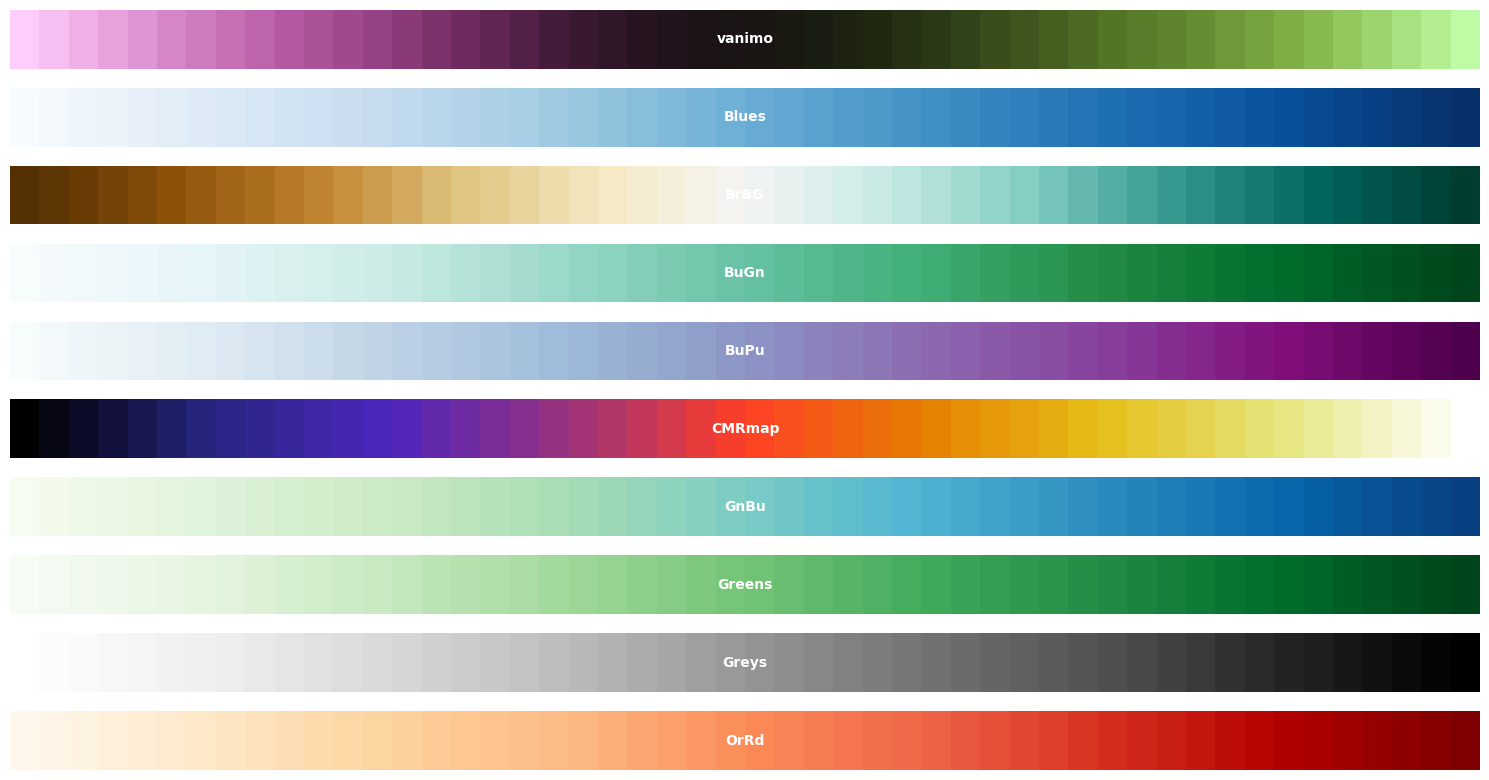

In [22]:
x= np.linspace(0, 100)
img = np.row_stack((x,x))

start= 10
finish= 20
n = finish-start
fig, axs = plt.subplots(n, 1, figsize=(1.5*n, 8))

ax= axs.ravel()
for i, colorname in enumerate(all_cmaps[start:finish]):
    ax[i].imshow(img, cmap=colorname)
    ax[i].text(0.5, 0.5, s=colorname, ha='center', va='center', color='white', weight='bold',
               transform= ax[i].transAxes)
    ax[i].axis('off')
fig.tight_layout()
plt.show()

### Using Colormaps Directly

Once you have a colormap object, you can call it like a function to get colors.

In [23]:
# Using colormap as a function
viridis = plt.get_cmap('viridis')

In [24]:
# Get single color at position 0.5 (middle of colormap)
mid_color = viridis(0.5)
mid_color

(np.float64(0.127568),
 np.float64(0.566949),
 np.float64(0.550556),
 np.float64(1.0))

In [25]:
# Get array of colors
positions = np.linspace(0, 1, 5)
colors = viridis(positions)
colors

array([[0.267004, 0.004874, 0.329415, 1.      ],
       [0.229739, 0.322361, 0.545706, 1.      ],
       [0.127568, 0.566949, 0.550556, 1.      ],
       [0.369214, 0.788888, 0.382914, 1.      ],
       [0.993248, 0.906157, 0.143936, 1.      ]])

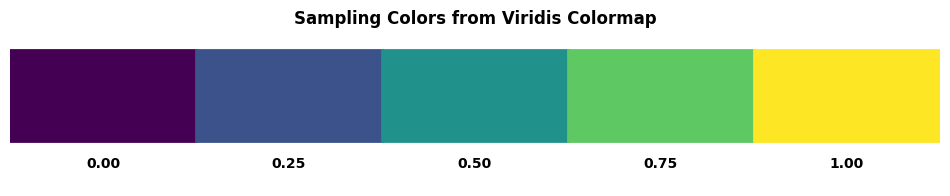

In [26]:
# Visualize
fig, ax = plt.subplots(figsize=(12, 2))
for i, (pos, color) in enumerate(zip(positions, colors)):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color, edgecolor='black', linewidth=2))
    ax.text(i + 0.5, -0.3, f'{pos:.2f}', ha='center', size=10, weight='bold')

ax.set_xlim(0, len(positions))
ax.set_ylim(-0.5, 1.2)
ax.set_title('Sampling Colors from Viridis Colormap', fontsize=12, fontweight='bold')
ax.axis('off')
plt.show()

## Creating and Customizing Colormaps

There are several ways to generate colormaps. How or what colormap you create will depend on several factors:
- Is the colormap for discrete or continuous values
- Is it based on existing ones or created from scratch?

### Discrete Colormaps `ListedColormap`

**`ListedColormap(colors, name='', N=None)`** creates a colormap from a list of discrete colors.

**When to use:** Categorical data, discrete intervals, custom color sequences, exact color control at specific positions

**Parameters:**
- `colors` - list of color specifications (required), can be names, RGB tuples, or hex codes
- `name` - colormap name (default: `''`), string
- `N` - number of entries (default: `len(colors)`), integer

In [27]:
categories.shape

(20, 30)

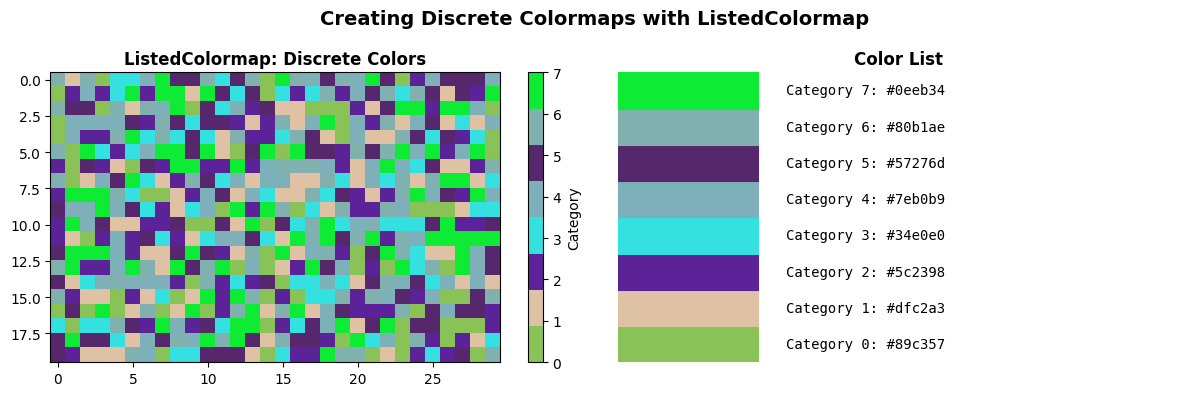

In [28]:
# Create discrete colormap from color list
n= 8
hex_colors= [mcolors.to_hex(rng.random(3)) for _ in range(n)] #creating three random color values 8 times
#using LIST COMPREHENSION (look up) (_ can be used sa placeholder  in python)                
discrete_cmap = ListedColormap(hex_colors, name='custom_discrete') #feeding that random assortment of colors to colormap

# Apply to categorical data
categories = rng.integers(0, n, size=(20, 30))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Discrete colormap
im1 = axes[0].imshow(categories, cmap=discrete_cmap, interpolation='nearest', aspect='auto')
axes[0].set_title('ListedColormap: Discrete Colors',size=12, weight='bold')
cbar1 = fig.colorbar(im1, ax=axes[0], ticks=range(8))
cbar1.set_label('Category')

# Show the color list
for i, color in enumerate(hex_colors):
    axes[1].add_patch(plt.Rectangle((0, i), 1, 1, color=color, edgecolor='black', lw=1.5))
    axes[1].text(1.2, i + 0.5, f'Category {i}: {color}', va='center',size=10, family='monospace')

axes[1].set_xlim(0, 4)
axes[1].set_ylim(0, n)
axes[1].set_title('Color List', size=12, weight='bold')
axes[1].axis('off')

fig.suptitle('Creating Discrete Colormaps with ListedColormap', size=14, fontweight='bold')
fig.tight_layout()
plt.show()

### `LinearSegmentedColormap` - Creating Smooth Gradients

**`LinearSegmentedColormap.from_list(name, colors, N=256)`** creates a smooth gradient colormap by interpolating between colors.

**When to use:** Continuous data, custom color transitions, smooth gradients between specific colors

**Parameters:**
- `name` - colormap name (required), string
- `colors` - list of colors to interpolate between (required). If 0 to 1 represents the entire colormap space, it is possible to specify where along this space we want each color. This is done by having a list of tuples (instead of colors) that include the position and color. E.g. (0.35, 'red´)
- `N` - number of discrete RGB quantization levels (default: `256`), integer

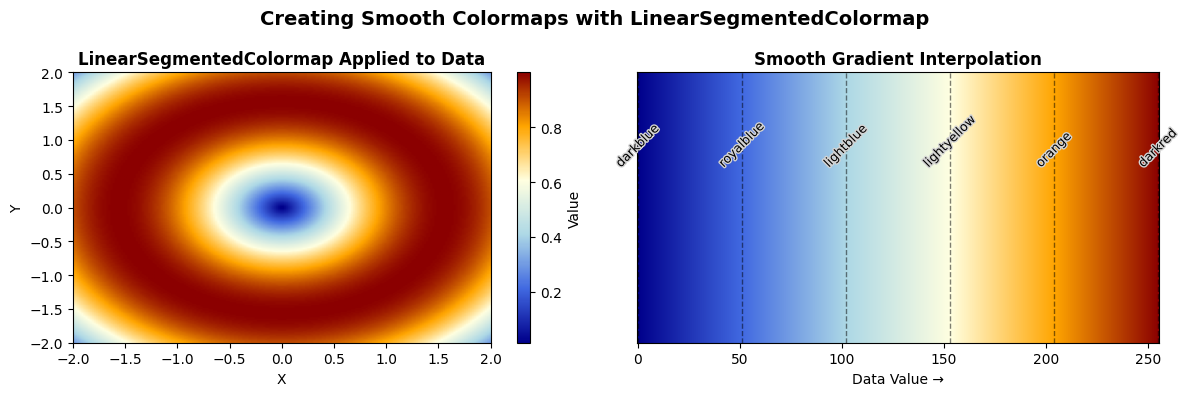

In [29]:
import matplotlib.patheffects as pe

# Simple color list
colors_gradient = ['darkblue', 'royalblue', 'lightblue', 'lightyellow', 'orange', 'darkred']
smooth_cmap = LinearSegmentedColormap.from_list('custom_smooth', colors_gradient, N=256)

# Apply to continuous data
x = np.linspace(-2, 2, 200)
y = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Apply colormap to data
im = axes[0].imshow(Z, cmap=smooth_cmap, aspect='auto', origin='lower', extent=[-2, 2, -2, 2])
axes[0].set_title('LinearSegmentedColormap Applied to Data', size=12, fontweight='bold')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
fig.colorbar(im, ax=axes[0], label='Value')

# Show gradient
gradient = np.linspace(0, 1, 256).reshape(1, 256)
axes[1].imshow(gradient, cmap=smooth_cmap, aspect='auto')
axes[1].set_title('Smooth Gradient Interpolation', size=12, weight='bold')
axes[1].set_yticks([])
axes[1].set_xlabel('Data Value →')

# Add color labels
for i, color in enumerate(colors_gradient):
    pos = i / (len(colors_gradient) - 1) * 255
    axes[1].axvline(pos, color='black', linestyle='--', alpha=0.5, lw=1)
    text = axes[1].text(pos, -0.15, s=color, color= 'black', ha='center', size=9, rotation=45)
    text.set_path_effects([pe.withStroke(linewidth=2, foreground='lightgray')])#creating a halo around the text

fig.suptitle('Creating Smooth Colormaps with LinearSegmentedColormap',size=14, fontweight='bold')
fig.tight_layout()
plt.show()

Next we specify the colors and the positions at which we want those colors to kick in, anything in between is interpolated.

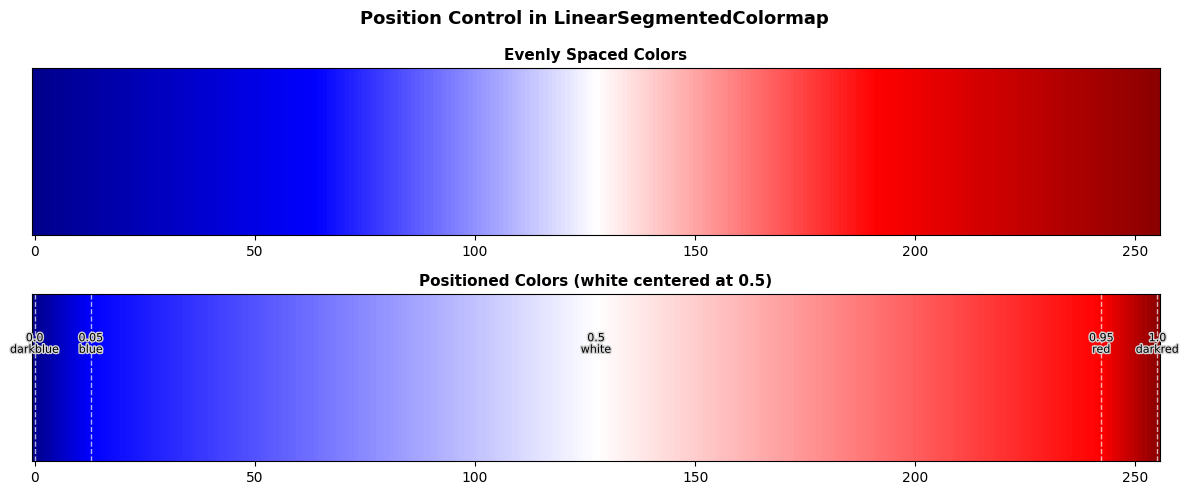

In [30]:
# Using position tuples for precise control
# Format: (position, color) where position is in [0, 1]

colors_with_positions = [
    (0.0, 'darkblue'),
    (0.05,  'blue'), # try 0.4, 0.1
    (0.5, 'white'),      # White at exact center
    (0.95, 'red'),  # try 0.6, 0.9
    (1.0, 'darkred')]

positioned_cmap = LinearSegmentedColormap.from_list('positioned', colors_with_positions)

fig, axes = plt.subplots(2, 1, figsize=(12, 5))

# Without positions (evenly spaced)
colors_only = ['darkblue', 'blue', 'white', 'red', 'darkred']
even_cmap = LinearSegmentedColormap.from_list('even', colors_only)

axes[0].imshow(gradient, cmap=even_cmap, aspect='auto')
axes[0].set_title('Evenly Spaced Colors', size=11, weight='bold')
axes[0].set_yticks([])

# With positions
axes[1].imshow(gradient, cmap=positioned_cmap, aspect='auto')
axes[1].set_title('Positioned Colors (white centered at 0.5)', size=11, weight='bold')
axes[1].set_yticks([])

# Mark positions
for pos, color_name in colors_with_positions:
    axes[1].axvline(pos * 255, color='white', ls='--', alpha=0.7, lw=1)
    text = axes[1].text(pos * 255, -0.15, f'{pos}\n{color_name}', ha='center', size=8)
    text.set_path_effects([pe.withStroke(linewidth=2, foreground='lightgray')])

fig.suptitle('Position Control in LinearSegmentedColormap', size=13, weight='bold')
fig.tight_layout()
fig.show()

### Modifying Existing Colormaps

You can modify existing colormaps by reversing them, extracting subsets, or adjusting properties.

In [31]:
# create data
gradient = np.linspace(0, 1, 256).reshape(1, 256)

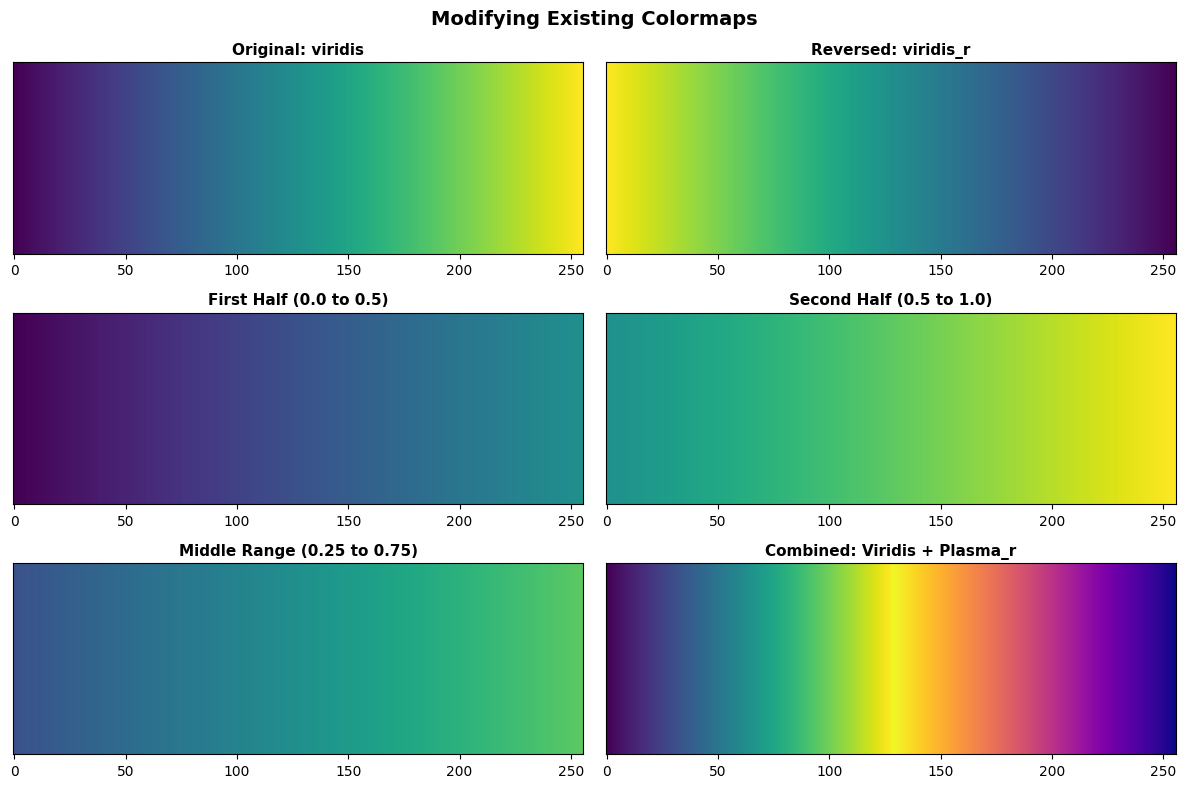

In [32]:
# Demonstrate colormap modifications
fig, axes = plt.subplots(3, 2, figsize=(12, 8))

# Original colormap
axes[0, 0].imshow(gradient, cmap='viridis', aspect='auto')
axes[0, 0].set_title('Original: viridis', size=11, weight='bold')
axes[0, 0].set_yticks([])

# Reversed (add '_r' suffix)
axes[0, 1].imshow(gradient, cmap='viridis_r', aspect='auto')
axes[0, 1].set_title('Reversed: viridis_r', size=11, weight='bold')
axes[0, 1].set_yticks([])

# Extract first half
first_half = np.linspace(0, 0.5, 256)                 
viridis = plt.get_cmap('viridis')
subset_first = ListedColormap(viridis(first_half))
axes[1, 0].imshow(gradient, cmap=subset_first, aspect='auto')
axes[1, 0].set_title('First Half (0.0 to 0.5)', size=11, weight='bold')
axes[1, 0].set_yticks([])

# Extract second half
second_half = np.linspace(0.5, 1, 256) 
subset_second = ListedColormap(viridis(second_half))
axes[1, 1].imshow(gradient, cmap=subset_second, aspect='auto')
axes[1, 1].set_title('Second Half (0.5 to 1.0)', size=11, weight='bold')
axes[1, 1].set_yticks([])

# Extract middle portion
subset= np.linspace(0.25, 0.75, 256)
subset_middle = ListedColormap(viridis(subset))
axes[2, 0].imshow(gradient, cmap=subset_middle, aspect='auto')
axes[2, 0].set_title('Middle Range (0.25 to 0.75)', size=11, weight='bold')
axes[2, 0].set_yticks([])

# Concatenate two colormaps
plasma_r = plt.get_cmap('plasma_r')
combined_colors = np.vstack([viridis(np.linspace(0, 1, 128)), 
                              plasma_r(np.linspace(0, 1, 128))])
combined_cmap = ListedColormap(combined_colors)
axes[2, 1].imshow(gradient, cmap=combined_cmap, aspect='auto')
axes[2, 1].set_title('Combined: Viridis + Plasma_r', size=11, weight='bold')
axes[2, 1].set_yticks([])

fig.suptitle('Modifying Existing Colormaps', size=14, weight='bold')
fig.tight_layout()
fig.show()

### Creating Colormaps with Segmentdata

**`LinearSegmentedColormap(name, segmentdata, N=256, gamma=1.0)`** creates a colormap with precise control over RGB channel transitions.

**When to use:** Complex color transitions requiring independent control of red, green, and blue channels, scientific colormaps with specific requirements

**Parameters:**

-`name` - String identifier for the colormap   
-`segmentdata` - Dictionary defining RGB channel transitions (see below)   
-`N` - Number of discrete RGB quantization levels (default: 256)   
-`gamma` - Gamma correction factor (default: 1.0), values > 1 emphasize high values, < 1 emphasize low values

`segmentdata`: Dictionary with keys 'red', 'green', 'blue', each containing a list of tuples:
```python
    segmentdata = {
    'red':   [(position, value_left, value_right), ...],
    'green': [(position, value_left, value_right), ...],
    'blue':  [(position, value_left, value_right), ...]
    }
```
    
Each tuple (*position*, *value_left*, *value_right*) means:

- *position*: Location in colormap from 0.0 to 1.0
- *value_left*: Color channel value (0-1) when approaching from the left
- *value_right*: Color channel value (0-1) when leaving to the right

Usually *value_left* == *value_right* for smooth transitions. They differ only when you want a discontinuous jump in color.

```{note} Understanding what we are modeling
We can use the `segmentdata` dictionary to specify how each RGB channels changes throughout the colormap from beginning to end .
```

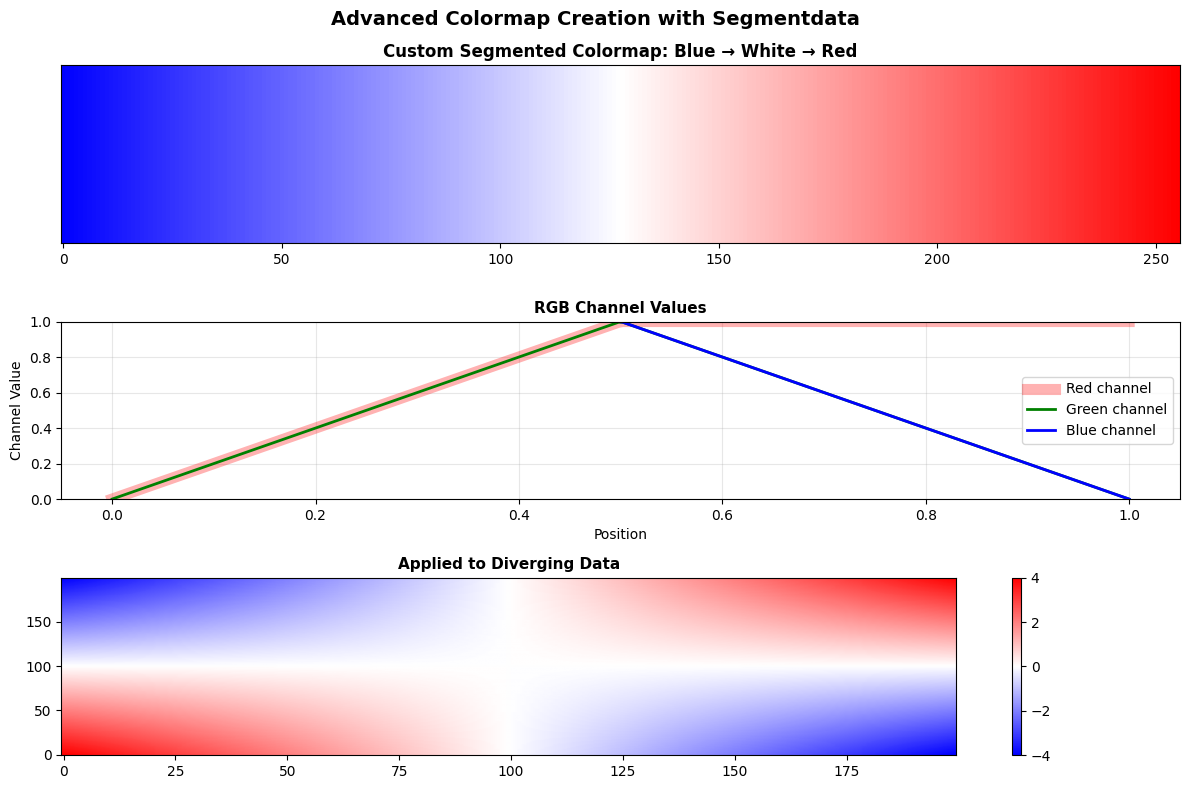

In [33]:
# Create custom colormap with segmentdata
# This creates a blue→white→red colormap with precise control
cdict = {
    'red':   [(0.0, 0.0, 0.0),   # At 0: no red
              (0.5, 1.0, 1.0),   # At 0.5: full red (white)
              (1.0, 1.0, 1.0)],  # At 1: full red
    
    'green': [(0.0, 0.0, 0.0),   # At 0: no green
              (0.5, 1.0, 1.0),   # At 0.5: full green (white)
              (1.0, 0.0, 0.0)],  # At 1: no green
    
    'blue':  [(0.0, 1.0, 1.0),   # At 0: full blue
              (0.5, 1.0, 1.0),   # At 0.5: full blue (white)
              (1.0, 0.0, 0.0)]   # At 1: no blue
}#so to tranistion from one full color to another,list only peaks bounded by zeros to make the value go up to the peak then down

segmented_cmap = LinearSegmentedColormap('blue_white_red', cdict, N=256)

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

# Show the colormap
axes[0].imshow(gradient, cmap=segmented_cmap, aspect='auto')
axes[0].set_title('Custom Segmented Colormap: Blue → White → Red', size=12, weight='bold')
axes[0].set_yticks([])

# Show RGB channel progression
x_vals = np.linspace(0, 1, 256)
rgb_colors = segmented_cmap(x_vals)

axes[1].plot(x_vals, rgb_colors[:, 0], 'r-', lw=8, label='Red channel', alpha= 0.3)
axes[1].plot(x_vals, rgb_colors[:, 1], 'g-', lw=2, label='Green channel')
axes[1].plot(x_vals, rgb_colors[:, 2], 'b-', lw=2, label='Blue channel')
axes[1].set_title('RGB Channel Values', size=11, weight='bold')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Channel Value')
axes[1].legend(loc='right')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1])

# Apply to diverging data
Z_div = X * Y
im = axes[2].imshow(Z_div, cmap=segmented_cmap, aspect='auto', origin='lower')
axes[2].set_title('Applied to Diverging Data', size=11, weight='bold')
fig.colorbar(im, ax=axes[2])

fig.suptitle('Advanced Colormap Creation with Segmentdata', fontsize=14, fontweight='bold')
fig.tight_layout()

plt.show()

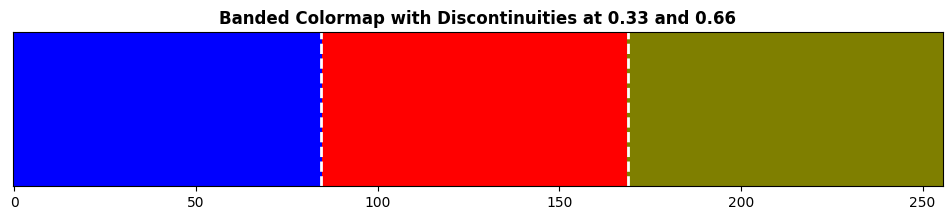

In [34]:
# Create colormap with 3 distinct color bands (no smooth transitions)
banded_dict = {
    'red':   [(0.0,  0.0, 0.0),
              (0.33, 0.0, 1.0),   # Jump from 0 to 1 at 0.33
              (0.66, 1.0, 0.5),   # Jump from 1 to 0.5 at 0.66
              (1.0,  0.5, 0.5)],
    
    'green': [(0.0,  0.0, 0.0),
              (0.33, 0.0, 0.0),
              (0.66, 0.0, 0.5),   # Jump from 0 to 0.5 at 0.66
              (1.0,  0.5, 0.5)],
    
    'blue':  [(0.0,  1.0, 1.0),
              (0.33, 1.0, 0.0),   # Jump from 1 to 0 at 0.33
              (0.66, 0.0, 0.0),
              (1.0,  0.0, 0.0)]
}

banded_cmap = LinearSegmentedColormap('banded', banded_dict, N=256)

fig, ax = plt.subplots(figsize=(12, 2))
ax.imshow(gradient, cmap=banded_cmap, aspect='auto')
ax.set_title('Banded Colormap with Discontinuities at 0.33 and 0.66', fontweight='bold')
ax.set_yticks([])
for pos in [0.33, 0.66]:
    ax.axvline(pos * 256, color='white', linewidth=2, linestyle='--')
plt.show()

## Color Normalization

### Normalization with `Normalize()`

**`Normalize()`**  maps data values linearly to [0, 1] range for colormap application

**When to use:**. To control which data values map to colormap **endpoints**. When you want to clip outliers to improve color distribution or make multiple plots share the same color scale.

**Parameters:**
- `vmin` - minimum data value (default: None, uses data min)
- `vmax` - maximum data value (default: None, uses data max)
- `clip` - whether to clip values outside [vmin, vmax] (default: False)

```{note} Using clip
Usually there will be not visual different using `clip = True` or not if `vmax` is set to a value less that the maximum of the data.
```

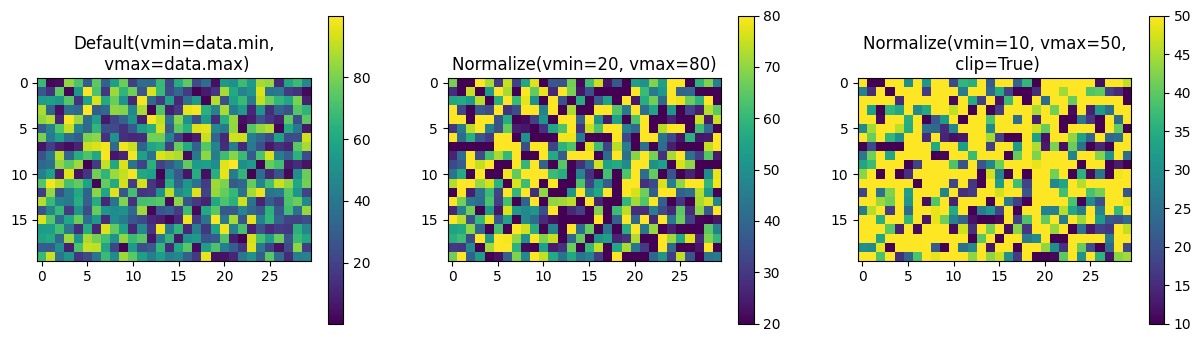

In [38]:
# Example 1: Default vs custom normalization
data = rng.random((20, 30)) * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Auto normalization
im1 = axes[0].imshow(data, cmap='viridis')
axes[0].set_title('Default(vmin=data.min,\n vmax=data.max)')
fig.colorbar(im1, ax=axes[0])

# Custom range
norm = Normalize(vmin=20, vmax=80)
im2 = axes[1].imshow(data, cmap='viridis', norm=norm)
axes[1].set_title('Normalize(vmin=20, vmax=80)')
fig.colorbar(im2, ax=axes[1])

# Clipping outliers
norm_clip = Normalize(vmin=10, vmax=50, clip=True)
im3 = axes[2].imshow(data, cmap='viridis', norm=norm_clip)
axes[2].set_title('Normalize(vmin=10, vmax=50,\n clip=True)')
fig.colorbar(im3, ax=axes[2])

plt.show()

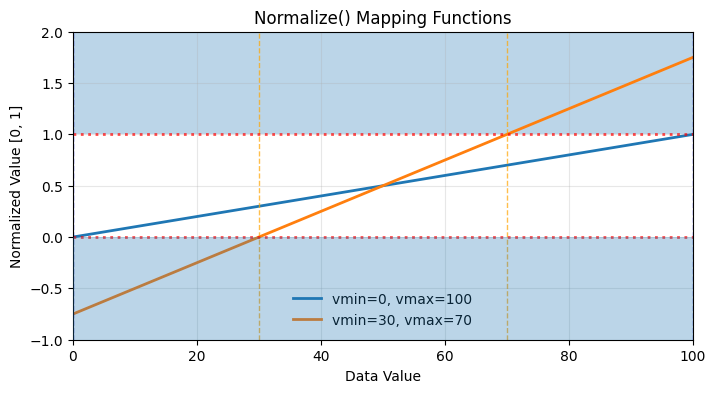

In [39]:
from matplotlib.patches import Rectangle

x_range = np.linspace(0, 100, 1000)
norm_default = Normalize(vmin=0, vmax=100)
norm_narrow = Normalize(vmin=30, vmax=70)

#lines
vertical_lines= [(30,'orange'),
                 (70,'orange'),
                 (0,'blue'),
                 (100,'blue')]
horizontal_lines= [(0,'red'),
                   (1,'red')]


fig, ax = plt.subplots(figsize=(8, 4))

# Zones
z1 = Rectangle((0,-1.0), height=1.0, width= 100, alpha=0.3, transform= ax.transData, zorder= 10)
ax.add_patch(z1)
z2 = Rectangle((0,1.0), height=1.0, width= 100, alpha=0.3, transform= ax.transData)
ax.add_patch(z2)

ax.plot(x_range, norm_default(x_range), label='vmin=0, vmax=100', linewidth=2)
ax.plot(x_range, norm_narrow(x_range), label='vmin=30, vmax=70', linewidth=2)

# plotting lines
for x, color in vertical_lines:
    ax.axvline(x, color= color, ls='--', lw=1.0, alpha= 0.7)
for y, color in horizontal_lines:
    ax.axhline(y, color= color, ls=':', lw=2.0, alpha= 0.7)

ax.set_xlim(0,100)
ax.set_ylim(-1.0, 2.0)
ax.set_xlabel('Data Value')
ax.set_ylabel('Normalized Value [0, 1]')
ax.set_title('Normalize() Mapping Functions')
ax.legend(framealpha= 0.5, frameon= False)
ax.grid(True, alpha=0.3)

plt.show()

### Custom Normalization with `TwoSlopeNorm()`

**`TwoSlopeNorm(vcenter, vmin=None, vmax=None)`** creates a normalization with different scaling on either side of a center point, useful for diverging data where you want to emphasize deviations from a central value.

**When to use:** Data with asymmetric ranges around a center (e.g. any diverging data where the ranges above and below center are unequal).

**Parameters:**
- `vcenter` - center point value where colormap midpoint is anchored (required), numeric
- `vmin` - minimum data value (default: `None`, uses data min), numeric
- `vmax` - maximum data value (default: `None`, uses data max), numeric

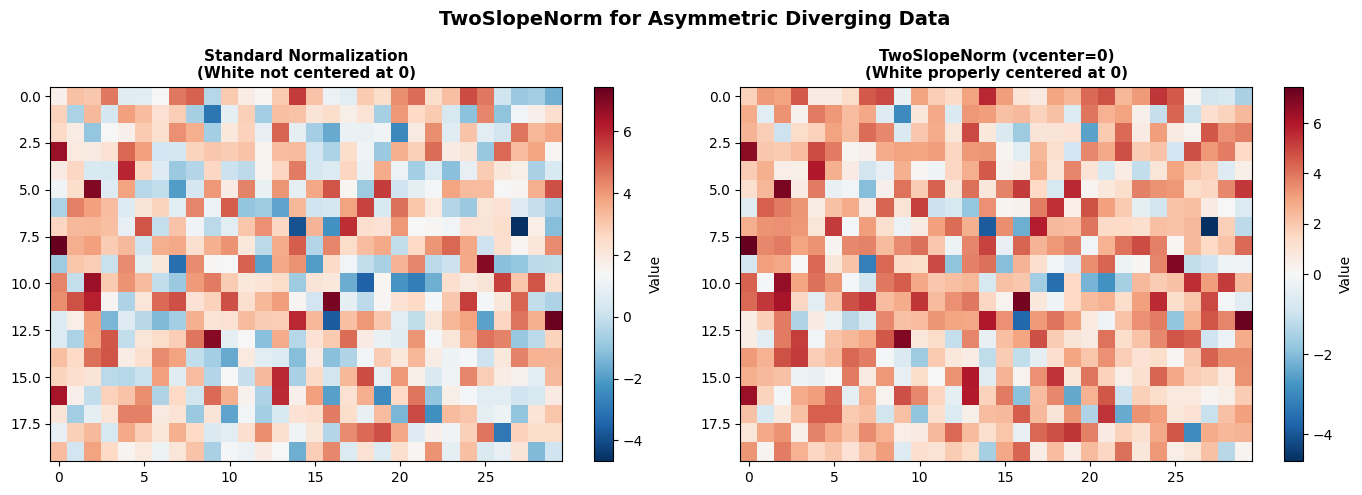

Data range: [-4.67, 7.45]
Without TwoSlopeNorm: White would appear at 1.39
With TwoSlopeNorm: White appears at 0.0 (as intended)


In [43]:
# Example 1: Asymmetric diverging data
    
# Create data with asymmetric range: [-2, +6]
data = rng.standard_normal((20, 30)) * 2
data = data + 2  # Shift so range is roughly [-2, 6]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Standard normalization - center not at visual midpoint
im1 = axes[0].imshow(data, cmap='RdBu_r', aspect='auto')
axes[0].set_title('Standard Normalization\n(White not centered at 0)', size=11, weight='bold')
cbar1 = fig.colorbar(im1, ax=axes[0])
cbar1.set_label('Value')

# TwoSlopeNorm - center white at 0
norm = TwoSlopeNorm(vcenter=0, vmin=data.min(), vmax=data.max())
im2 = axes[1].imshow(data, cmap='RdBu_r', norm=norm, aspect='auto')
axes[1].set_title('TwoSlopeNorm (vcenter=0)\n(White properly centered at 0)', size=11, weight='bold')
cbar2 = fig.colorbar(im2, ax=axes[1])
cbar2.set_label('Value')

fig.suptitle('TwoSlopeNorm for Asymmetric Diverging Data', size=14, weight='bold')
fig.tight_layout()
plt.show()

print(f"Data range: [{data.min():.2f}, {data.max():.2f}]")
print(f"Without TwoSlopeNorm: White would appear at {(data.min() + data.max())/2:.2f}")
print(f"With TwoSlopeNorm: White appears at 0.0 (as intended)")

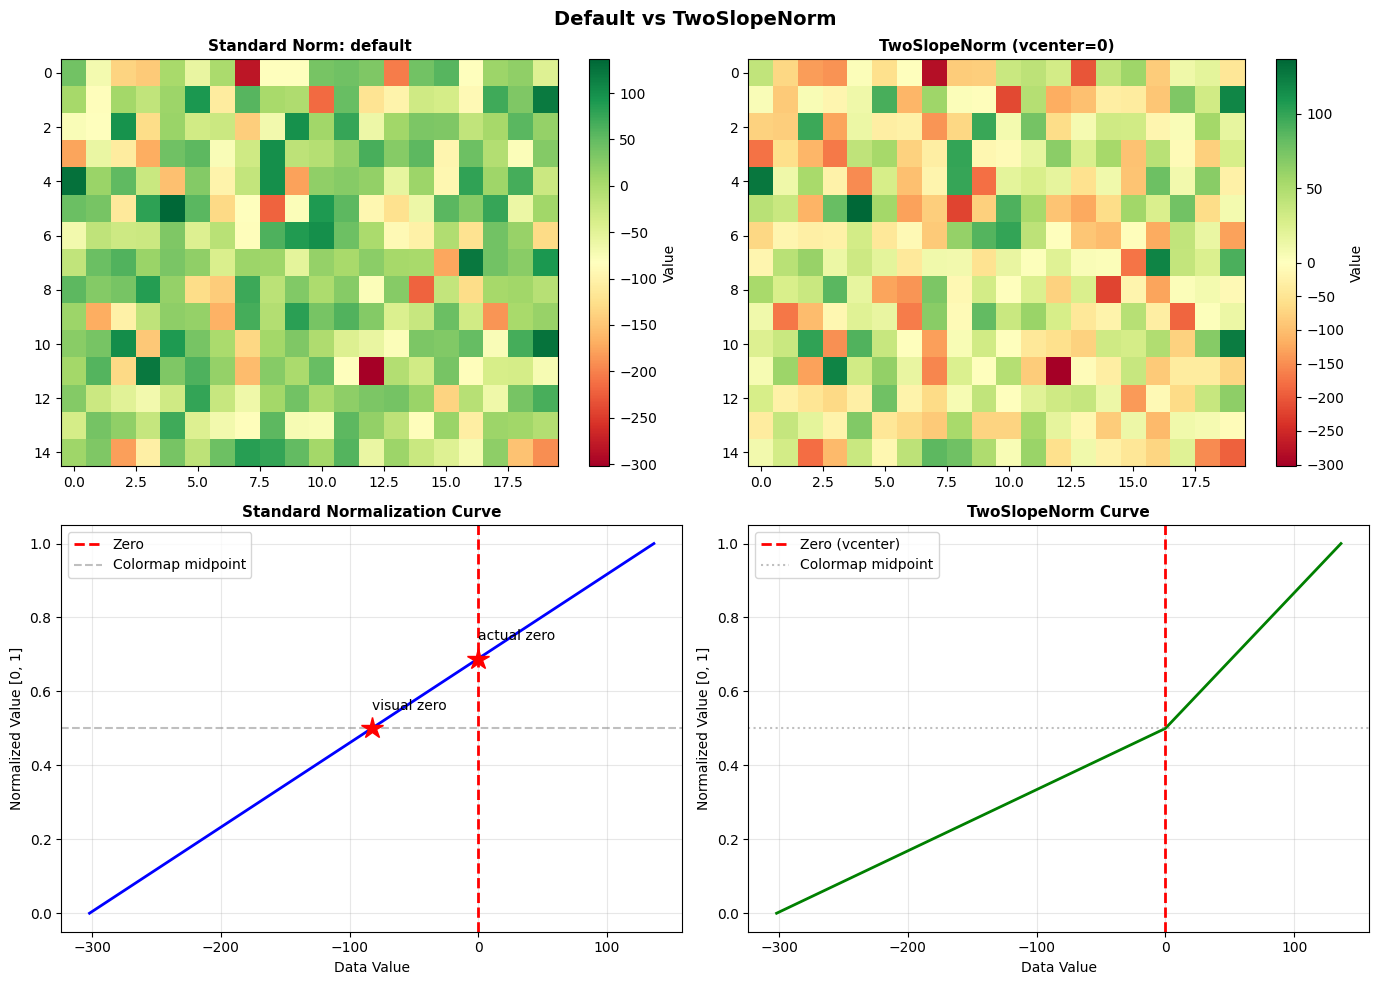

In [44]:
# Simulate profit/loss data where losses can be larger
data = rng.standard_normal((15, 20)) * 50
data[data < 0] *= 2  # Losses are twice as large

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Standard normalization
im1 = axes[0, 0].imshow(data, cmap='RdYlGn', aspect='auto')
axes[0, 0].set_title('Standard Norm: default', size=11, weight='bold')
fig.colorbar(im1, ax=axes[0, 0], label='Value')

# TwoSlopeNorm centered at 0
norm_zero = TwoSlopeNorm(vcenter=0, vmin=data.min(), vmax=data.max())
im2 = axes[0, 1].imshow(data, cmap='RdYlGn', norm=norm_zero, aspect='auto')
axes[0, 1].set_title('TwoSlopeNorm (vcenter=0)', size=11, weight='bold')
fig.colorbar(im2, ax=axes[0, 1], label='Value')

# Visualize the normalization curves
x_range = np.linspace(data.min(), data.max(), 1000)

# Standard normalization curve
standard_norm = Normalize(vmin=data.min(), vmax=data.max())
axes[1, 0].plot(x_range, standard_norm(x_range), 'b-', lw=2) # line representing how xrange maps to [0,1]
axes[1, 0].axvline(0, color='red', ls='--', lw=2, label='Zero')
axes[1, 0].axhline(0.5, color='gray', ls='--', alpha=0.5, label='Colormap midpoint')

axes[1,0].plot(x_range[500], 0.5, 'r*', ms= 16)
axes[1,0].text(x_range[500], 0.5+0.05, s='visual zero', transform=axes[1,0].transData)

axes[1,0].plot(0, standard_norm(0.0), 'r*', ms= 16)
axes[1,0].text(0, standard_norm(0.0)+0.05, s='actual zero', transform=axes[1,0].transData)

axes[1, 0].set_title('Standard Normalization Curve', size=11, weight='bold')
axes[1, 0].set_xlabel('Data Value')
axes[1, 0].set_ylabel('Normalized Value [0, 1]')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# TwoSlopeNorm curve
axes[1, 1].plot(x_range, norm_zero(x_range), 'g-', linewidth=2)
axes[1, 1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero (vcenter)')
axes[1, 1].axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Colormap midpoint')
axes[1, 1].set_title('TwoSlopeNorm Curve', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Data Value')
axes[1, 1].set_ylabel('Normalized Value [0, 1]')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle('Default vs TwoSlopeNorm', size=14, fontweight='bold')
fig.tight_layout()
plt.show()

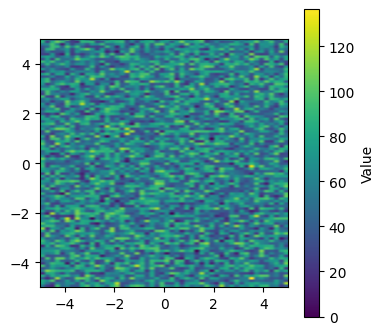

In [45]:
# Create an image with two peaks

# Two normal distributions with different means
peak1 = rng.normal(loc=20, scale=10, size=(50, 50))
peak2 = rng.normal(loc=60, scale=12, size=(50, 50))

# Stack them
data_tmp = np.vstack([peak1, peak2])

# Add noise
noise = rng.normal(loc=40, scale=15, size=data_tmp.shape)  # Random noise everywhere
data_noisy = data_tmp + noise * 0.5

# reshuffle 
data = rng.permutation(data_noisy.flatten()).reshape(data_tmp.shape)

# visualize
fig, ax = plt.subplots(figsize=(4,4))
im = ax.imshow(data, cmap='viridis',extent=[-5, 5, -5, 5])
fig.colorbar(im, label='Value', ax= ax)
plt.show()

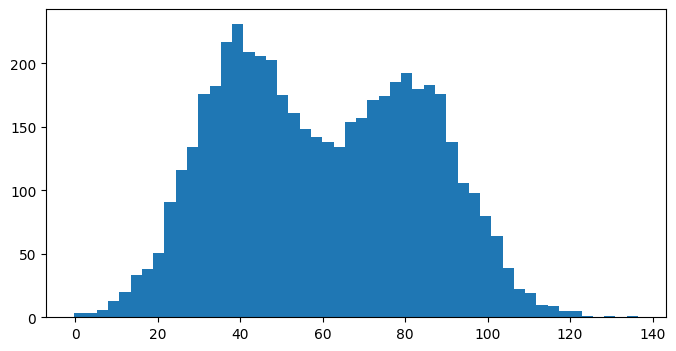

In [50]:
# histogram of values
fig, ax= plt.subplots(figsize= (8, 4))
counts, bins, patches = ax.hist(data.flatten(), bins=50)
plt.show()

We could find a more precise way to determine where we have the peaks but here we will just eyeball the histogram and decide that peaks are at x= 40 and 80. If we normalize the x range between [0,1] we want to find out the values of x=40, 80 in relation to [0,1]. 

In [ ]:
# minimum value
n()

In [53]:
# normalize all data values
norm = Normalize(vmin=data.min(), vmax=data.max())

In [54]:
# find values at x= 40, 80
norm(40), norm(80)

(np.float64(0.29445470751951736), np.float64(0.5870735172186796))

In [55]:
def adjust_cbar(ax, cbar):
    '''adjusts colorbar to axes height'''
    ax_pos = ax.get_position()
    cbar_pos = cbar.ax.get_position()

    # Set colorbar to match BOTH bottom position and height
    cbar.ax.set_position([cbar_pos.x0, ax_pos.y0, cbar_pos.width, ax_pos.height])
    return ax, cbar

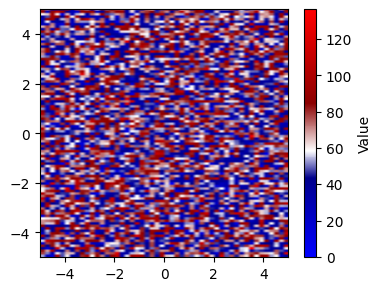

In [57]:
colors_with_positions = [
    (0.0, 'blue'),
    (0.32, 'darkblue'), #darks on the iinside to show bimodal peak
    (0.43, 'white'),  
    (0.62, 'darkred'),  
    (1.0, 'red')]

positioned_cmap = LinearSegmentedColormap.from_list('positioned', colors_with_positions)

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(data, cmap=positioned_cmap, extent=[-5, 5, -5, 5])
cbar = fig.colorbar(im, label='Value', ax=ax)
adjust_cbar(ax,cbar)

plt.show()

## Best Practices and Resources

### Common Pitfalls to Avoid

Understanding what not to do is as important as knowing best practices.

**AVOID**
- Don't use 'jet' or 'rainbow' - creates false boundaries
- Don't use sequential colormaps for diverging data
- Don't ignore colorblind accessibility
- Don't use qualitative colormaps for continuous data

**ACCESSIBILITY**
- Use perceptually uniform colormaps: viridis, plasma, cividis
- Avoid red-green combinations (~8% of males have red-green color visual deviciency or CVD)
- Test visualizations with CVD simulators (e.g., Viz Palette)
- Provide alternative encodings when possible (patterns, labels)
- Consider grayscale conversion - does it still convey information?

### Online Resources for Color Selection

Several online tools help select effective, accessible color schemes.

**When to use [ColorBrewer](https://colorbrewer2.org):**
- Selecting color palettes for maps and geographic data
- Need print-friendly color schemes
- Require colorblind-safe categorical palettes
- Want scientifically-tested color combinations

**When to use [Viz Palette](https://projects.susielu.com/viz-palette):**
- Testing chosen colors for color vision deficiency simulation
- Checking contrast and distinguishability
- Simulating different types of CVD (deuteranopia, protanopia, tritanopia)
- Ensuring accessibility compliance

**When to use [Adobe Color](https://color.adobe.com):**
- Creating color schemes based on color theory (complementary, triadic, etc.)
- Extracting palettes from images
- Exploring trending color combinations

**When to use [COOLORS](https://coolors.co):**
- Best for: Quick color scheme generation, exploration
- Features: Generate palettes, extract from images, trending colors
- Use when: Need inspiration or harmonious color combinations
#### Other (some repeated functionality)

- [Colourspacious](https://colorspacious.readthedocs.io/en/latest/index.html)
- [Color Science](https://www.colour-science.org/)
- [Python Colormath](https://python-colormath.readthedocs.io/en/latest/)
- [ciecam02](https://github.com/dannyvi/ciecam02)

#### Tips

- [What to consider when choosing colors for data visualization](https://www.datawrapper.de/blog/colors)
